#EDA

In [11]:
import sys
import os
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose

sys.path.append(os.path.abspath('..'))

from src.data_loader import load_raw_data
from src.preprocessing import replace_nulls, impute_missing_values

# Cấu hình matplotlib
plt.style.use('ggplot')

In [12]:

raw_path = '../data/raw/AirQualityUCI.csv'
df = load_raw_data(raw_path)

df_nan = replace_nulls(df)

df_clean = impute_missing_values(df_nan)

display(df_clean.head())
print("\nSố lượng null hiện tại:\n", df_clean.isna().sum())

Đang đọc dữ liệu từ: ../data/raw/AirQualityUCI.csv ...
Dữ liệu đã load thành công! Kích thước: (9357, 13)
Đang thay thế giá trị -200 thành NaN...
Tổng số giá trị khuyết (NaN) sau khi chuyển đổi: 16701
Đang tiến hành nội suy dữ liệu khuyết...
Đã hoàn tất điền dữ liệu khuyết.


,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
Datetime,,,,,,,,,,,,,
2004-10-03 18:00:00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
2004-10-03 19:00:00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2004-10-03 20:00:00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
2004-10-03 21:00:00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
2004-10-03 22:00:00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888



Số lượng null hiện tại:
 CO(GT)           0
PT08.S1(CO)      0
NMHC(GT)         0
C6H6(GT)         0
PT08.S2(NMHC)    0
NOx(GT)          0
PT08.S3(NOx)     0
NO2(GT)          0
PT08.S4(NO2)     0
PT08.S5(O3)      0
T                0
RH               0
AH               0
dtype: int64



--- BẢNG THỐNG KÊ MÔ TẢ ---
                      mean         std       min       max
CO(GT)            2.091321    1.397065    0.1000    11.900
PT08.S1(CO)    1101.465269  218.284913  647.0000  2040.000
NMHC(GT)        123.557695  102.246107    7.0000  1189.000
C6H6(GT)         10.139266    7.518983    0.1000    63.700
PT08.S2(NMHC)   940.530528  268.567344  383.0000  2214.000
NOx(GT)         234.720342  203.271451    2.0000  1479.000
PT08.S3(NOx)    833.791093  255.821736  322.0000  2683.000
NO2(GT)         108.370334   46.594830    2.0000   340.000
PT08.S4(NO2)   1452.831563  344.627485  551.0000  2775.000
PT08.S5(O3)    1028.820626  402.225332  221.0000  2523.000
T                18.213864    8.810001   -1.9000    44.600
RH               49.329029   17.158089    9.2000    88.700
AH                1.021745    0.401448    0.1847     2.231


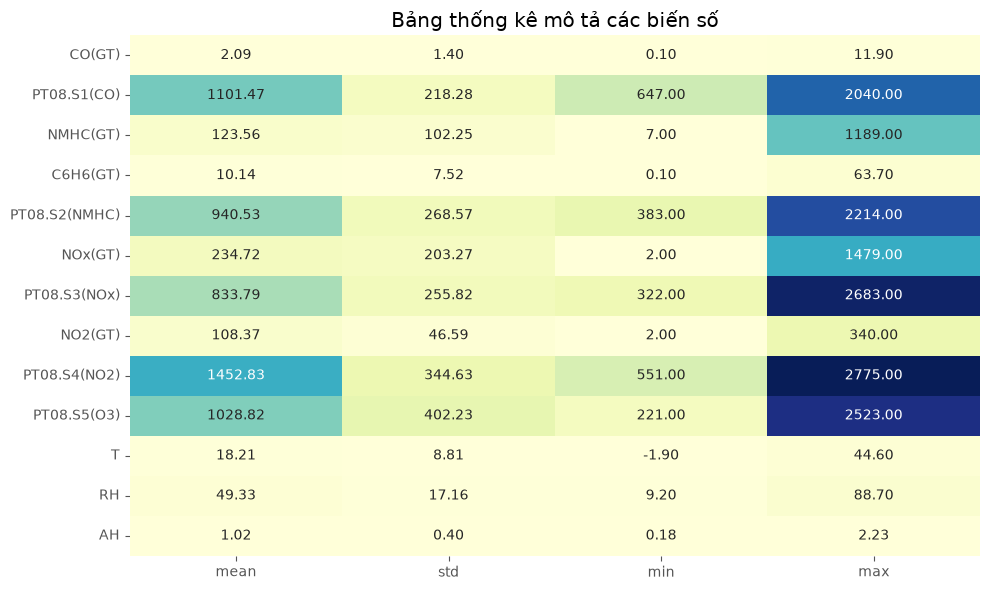

In [13]:
summary_stats = df_clean.describe().loc[['mean', 'std', 'min', 'max']].T
print("\n--- BẢNG THỐNG KÊ MÔ TẢ ---")
print(summary_stats)

plt.figure(figsize=(10, 6))
sns.heatmap(summary_stats, annot=True, fmt=".2f", cmap='YlGnBu', cbar=False)
plt.title('Bảng thống kê mô tả các biến số')
plt.tight_layout()
plt.savefig('../reports/figures/descriptive_statistics.png', dpi=300)
plt.show()


Đang phân tích xu hướng thời gian cho biến: T...


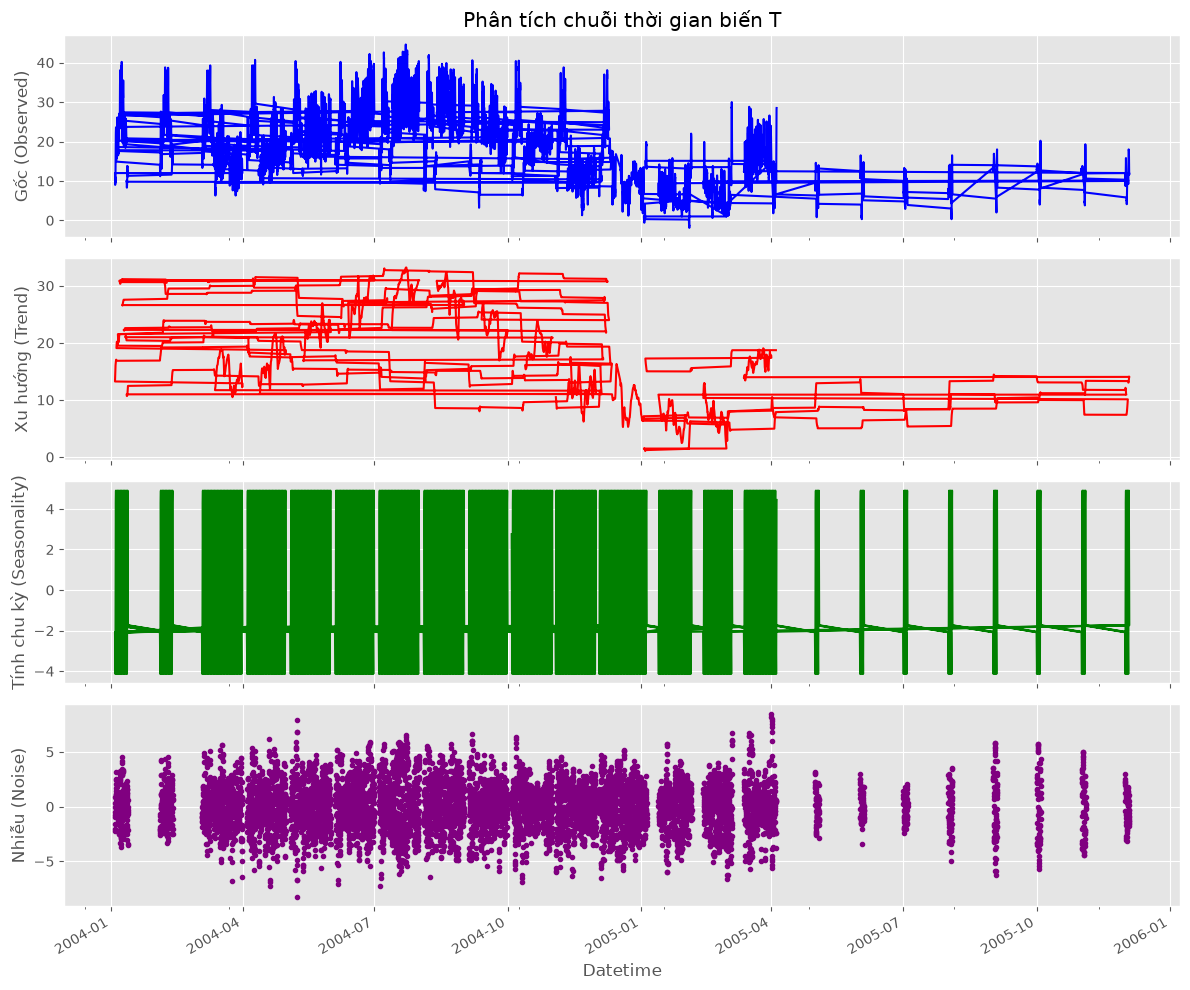

In [14]:
target_column = 'T' 

if target_column in df_clean.columns:
    print(f"\nĐang phân tích xu hướng thời gian cho biến: {target_column}...")
    decomposition = seasonal_decompose(df_clean[target_column].dropna(), model='additive', period=24)
    
    fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
    
    decomposition.observed.plot(ax=ax1, color='blue')
    ax1.set_title(f'Phân tích chuỗi thời gian biến {target_column}')
    ax1.set_ylabel('Gốc (Observed)')
    
    decomposition.trend.plot(ax=ax2, color='red')
    ax2.set_ylabel('Xu hướng (Trend)')
    
    decomposition.seasonal.plot(ax=ax3, color='green')
    ax3.set_ylabel('Tính chu kỳ (Seasonality)')
    
    decomposition.resid.plot(ax=ax4, color='purple', style='.')
    ax4.set_ylabel('Nhiễu (Noise)')
    
    plt.tight_layout()
    # plt.savefig(f'../reports/figures/{target_column}_time_series_decomposition.png', dpi=300)
    plt.show()
else:
    print(f"\nKhông tìm thấy cột '{target_column}' để phân tích chuỗi thời gian. Vui lòng đổi tên cột phù hợp.")

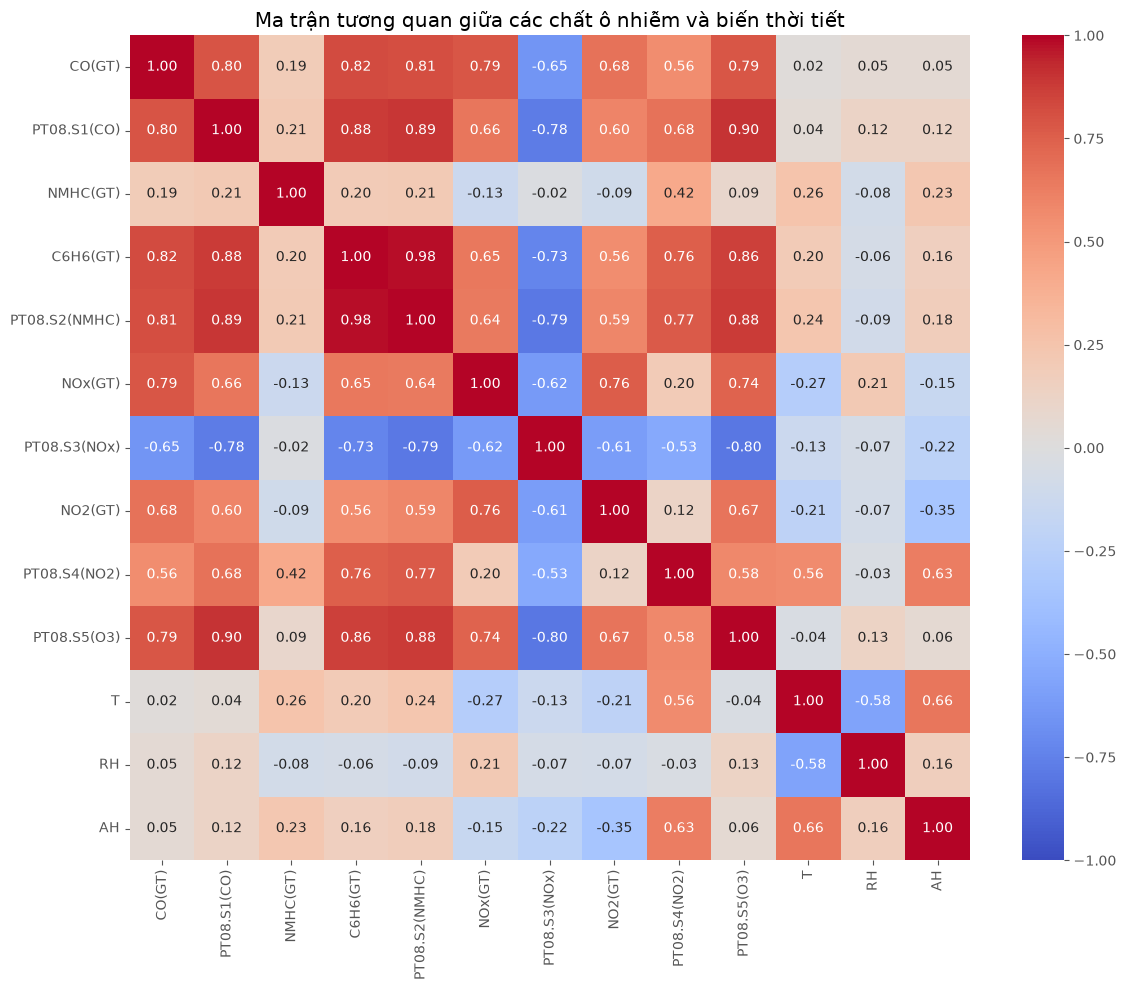

Đã lưu dữ liệu sạch vào data/processed/clean_data.csv


In [15]:
corr_matrix = df_clean.corr()

plt.figure(figsize=(12, 10))

sns.heatmap(corr_matrix, 
            annot=True,        
            fmt=".2f",         
            cmap='coolwarm',  
            vmin=-1, vmax=1)

plt.title('Ma trận tương quan giữa các chất ô nhiễm và biến thời tiết')
plt.tight_layout()

os.makedirs('../reports/figures', exist_ok=True)
plt.savefig('../reports/figures/correlation_matrix.png', dpi=300)
plt.show()

os.makedirs('../data/processed', exist_ok=True)
df_clean.to_csv('../data/processed/clean_data.csv')
print("Đã lưu dữ liệu sạch vào data/processed/clean_data.csv")